# Predicting Daily Milk Yield of Dairy Cows

This notebook builds, evaluates, and interprets regression models that predict a dairy cow's **daily milk yield (litres)** from feeding, environmental, and animal-related characteristics.

## Mission

Guided by my core values of community and innovation, my mission is to use software engineering and data analysis to build the practical tools and unlock the critical insights that empower Busoga's livestock farmers. I am driven to help them increase profitability, improve local nutrition, and create sustainable jobs by providing greater access to actionable information.

## Problem Statement

Small-scale dairy farmers in Busoga often make feeding and livestock management decisions **without knowing how those decisions affect milk production**. As a result, milk production becomes inconsistent and Profitability decreases.

This project builds a machine learning model that predicts the **expected daily milk yield of a dairy cow** based on feeding, environmental, and animal-related characteristics. The prediction can help farmers make informed management decisions that improve productivity and profitability.

## Dataset Description

The dataset contains **250,000 records and 37 columns** describing individual dairy cattle and their daily milk production. Each row represents one cow on one day.

## Dataset Source

- **Name:** Cattle Health and Feeding Data
- **File used:** global_cattle_milk_yield_prediction_dataset.csv
- **Platform:** Kaggle
- **Link:** https://www.kaggle.com/datasets/shahhet2812/cattle-health-and-feeding-data
- **Owner:** shahhet2812


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42 #used everywhere we need reproducibility (train/test split, model initialization), so re-running the notebook always gives the same results.

## Load Dataset

In [ ]:
DATA_PATH = "data/raw/global_cattle_milk_yield_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.shape

(250000, 37)

In [ ]:
df.head()

,Cattle_ID,Breed,Region,Country,Climate_Zone,Management_System,Age_Months,Weight_kg,Parity,Lactation_Stage,Days_in_Milk,Feed_Type,Feed_Quantity_kg,Feeding_Frequency,Water_Intake_L,Walking_Distance_km,Grazing_Duration_hrs,Rumination_Time_hrs,Resting_Hours,Ambient_Temperature_C,Humidity_percent,Season,Housing_Score,FMD_Vaccine,Brucellosis_Vaccine,HS_Vaccine,BQ_Vaccine,Anthrax_Vaccine,IBR_Vaccine,BVD_Vaccine,Rabies_Vaccine,Previous_Week_Avg_Yield,Body_Condition_Score,Milking_Interval_hrs,Date,Farm_ID,Milk_Yield_L
0,CATTLE_000001,Tharparkar,Africa,CA,Tropical,Intensive,32,259.9,4,Late,352,Hay,16.8,3,58.5,7.89,1.6,4.3,8.4,24.9,66.9,Summer,0.57,0,1,1,1,1,0,0,0,4.88,3.0,24,2023-02-06,FARM_0825,3.08
1,CATTLE_000002,Africander,South_America,ET,Arid,Semi_Intensive,63,593.9,6,Early,325,Dry_Fodder,8.9,3,57.8,4.01,5.5,11.3,11.1,34.0,46.2,Summer,0.77,1,0,0,1,0,0,1,1,3.52,2.5,24,2022-10-31,FARM_0106,2.00
2,CATTLE_000003,Holstein-Friesian,Oceania,KE,Temperate,Intensive,132,675.4,3,Mid,79,Crop_Residues,3.0,3,75.3,2.08,3.8,9.8,12.0,45.0,78.3,Autumn,0.54,1,0,0,1,1,0,1,0,11.28,2.5,12,2024-11-01,FARM_0201,14.06
3,CATTLE_000004,Fleckvieh,Europe_NA,BR,Tropical,Semi_Intensive,73,260.5,5,Late,249,Crop_Residues,10.6,1,90.3,3.60,6.8,7.1,8.9,34.0,34.9,Spring,0.69,0,0,0,1,0,0,0,0,10.63,4.0,8,2023-07-07,FARM_0174,12.74
4,CATTLE_000005,Danish_Red,Oceania,US,Subtropical,Extensive,50,477.8,6,Early,339,Concentrates,14.3,3,57.3,4.09,1.0,5.2,12.0,33.1,100.0,Summer,0.83,0,0,0,1,0,1,1,1,16.99,2.0,12,2024-09-20,FARM_0028,15.64


## Exploratory Data Analysis (EDA)
Before touching the data, we need to understand its shape and behaviour: how many columns of each type we have, what range the numeric features cover, and how many distinct categories each text column holds.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Cattle_ID                250000 non-null  str    
 1   Breed                    250000 non-null  str    
 2   Region                   250000 non-null  str    
 3   Country                  250000 non-null  str    
 4   Climate_Zone             250000 non-null  str    
 5   Management_System        250000 non-null  str    
 6   Age_Months               250000 non-null  int64  
 7   Weight_kg                250000 non-null  float64
 8   Parity                   250000 non-null  int64  
 9   Lactation_Stage          250000 non-null  str    
 10  Days_in_Milk             250000 non-null  int64  
 11  Feed_Type                250000 non-null  str    
 12  Feed_Quantity_kg         250000 non-null  float64
 13  Feeding_Frequency        250000 non-null  int64  
 14  Water_Intake_L 

**Interpretation:** all 37 columns report 250,000 non-null values, confirming there is no missing data anywhere 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age_Months,250000.0,83.450064,34.642854,24.0,53.00,83.00,113.00,143.00
Weight_kg,250000.0,500.118658,144.458104,250.0,374.80,500.40,625.50,750.00
Parity,250000.0,3.500152,1.706973,1.0,2.00,3.00,5.00,6.00
Days_in_Milk,250000.0,182.277176,105.104091,1.0,91.00,182.00,273.00,364.00
Feed_Quantity_kg,250000.0,12.015175,3.959998,3.0,9.30,12.00,14.70,25.00
Feeding_Frequency,250000.0,3.000660,1.412508,1.0,2.00,3.00,4.00,5.00
Water_Intake_L,250000.0,65.074433,19.699541,20.0,51.50,65.00,78.50,120.00
Walking_Distance_km,250000.0,4.037237,1.927741,0.5,2.66,4.01,5.35,12.00
Grazing_Duration_hrs,250000.0,6.053517,2.867527,1.0,4.00,6.00,8.00,14.00
Rumination_Time_hrs,250000.0,8.010312,1.953905,4.0,6.60,8.00,9.30,14.00


**Interpretation:**

**Target variable, Milk_Yield_L** ranges from 0 to 36.42 L, with a mean of 8.72 L and median of 7.62 L. The mean sitting above the median tells us the distribution is **right-skewed** - most cows produce a modest amount of milk, with a smaller number of high-yield cows pulling the average up. We confirm this visually in the Visualizations 

In [ ]:
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
df[categorical_cols].nunique().sort_values()

Lactation_Stage           3
Management_System         5
Season                    5
Region                    6
Climate_Zone              6
Feed_Type                 8
Country                  15
Breed                    40
Farm_ID                1000
Date                   1095
Cattle_ID            250000
dtype: int64

**Interpretation:** the above helps us understand the distinct categorical columns in our data

## Data Cleaning

We want to understand missing values, duplicate records, and data types. 

### Missing Values

In [ ]:
df.isnull().sum()

Cattle_ID                  0
Breed                      0
Region                     0
Country                    0
Climate_Zone               0
Management_System          0
Age_Months                 0
Weight_kg                  0
Parity                     0
Lactation_Stage            0
Days_in_Milk               0
Feed_Type                  0
Feed_Quantity_kg           0
Feeding_Frequency          0
Water_Intake_L             0
Walking_Distance_km        0
Grazing_Duration_hrs       0
Rumination_Time_hrs        0
Resting_Hours              0
Ambient_Temperature_C      0
Humidity_percent           0
Season                     0
Housing_Score              0
FMD_Vaccine                0
Brucellosis_Vaccine        0
HS_Vaccine                 0
BQ_Vaccine                 0
Anthrax_Vaccine            0
IBR_Vaccine                0
BVD_Vaccine                0
Rabies_Vaccine             0
Previous_Week_Avg_Yield    0
Body_Condition_Score       0
Milking_Interval_hrs       0
Date          

**Interpretation:** No missing values in our dataset

### Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
feature_cols = [c for c in df.columns if c not in ("Cattle_ID", "Farm_ID", "Date")]
df.duplicated(subset=feature_cols).sum()

np.int64(0)

**Interpretation:** No duplicates

### Data Types

Below, we fix the date (since date is stored as a string) and the vaccine columns (reducing the base of the integer) data types

In [ ]:
memory_before_mb = df.memory_usage(deep=True).sum() / 1e6

df["Date"] = pd.to_datetime(df["Date"])

vaccine_cols = [c for c in df.columns if c.endswith("_Vaccine")]
df[vaccine_cols] = df[vaccine_cols].astype("int8")

memory_after_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory before: {memory_before_mb:.2f} MB")
print(f"Memory after:  {memory_after_mb:.2f} MB")

Memory before: 209.68 MB
Memory after:  182.93 MB


**Interpretation:** converting Date to a real datetime64 type and the 8 vaccine flags to int8 brought memory usage down from about 210 MB to about 183 MB 

## Feature Engineering

This is where we shape the data specifically for our regression modelling. In this section, we have four decisions to make.

1. **Dropping columns** that cannot help a regression model generalize.
2. **Encoding categorical variables** into a numeric form models can use.
3. **Standardizing numeric variables**, especially important for gradient descent.
4. **Deciding when to fit these transformations** 

### 1. Dropping Columns

We drop five columns and keep the rest.

| Column | Why we drop it |
|---|---|
| Cattle_ID | It just a unique row identifier. Our model does not have to learn of a new cow added in Busoga |
| Farm_ID | same identifier problem |
| Date |***Season*** already captures the seasonal signal we actually care about. |
| Region, Country | We are only focussed on Busoga region, Uganda, so we do not need this |

Everything else stays, because it describes *feeding, environmental, or animal characteristics* - exactly the causal factors a farmer can act on.

In [ ]:
columns_to_drop = ["Cattle_ID", "Farm_ID", "Date", "Region", "Country"]

df_clean = df.drop(columns=columns_to_drop)
df_clean.shape

(250000, 32)

### 2. Encoding Categorical Variables

**df_clean** still has 6 text columns: Breed, Climate_Zone, Management_System, Lactation_Stage, Feed_Type, Seaso`. Regression models only understand numbers, so these need encoding. I am use **one-hot encoding** rather than label/ordinal encoding (turning each category into 0, 1, 2, 3...)


In [ ]:
categorical_features = df_clean.drop(columns=["Milk_Yield_L"]).select_dtypes(exclude="number").columns.tolist()
categorical_features

['Breed',
 'Climate_Zone',
 'Management_System',
 'Lactation_Stage',
 'Feed_Type',
 'Season']

### 3.Standardization

This is important because our remaining numeric features or columns have very different scales e.g Feed_Quantity_kg ranges roughly 3–25, Water_Intake_L ranges 20–120. During gradient descent, a feature with a much larger numeric range will not dominate the gradient and can make training unstable. I am using **StandardScaler** to transform every numeric feature to mean 0 and standard deviation 1, so they all contribute on equal scale.


In [ ]:
numeric_features = df_clean.drop(columns=["Milk_Yield_L"] + categorical_features).columns.tolist()
numeric_features

['Age_Months',
 'Weight_kg',
 'Parity',
 'Days_in_Milk',
 'Feed_Quantity_kg',
 'Feeding_Frequency',
 'Water_Intake_L',
 'Walking_Distance_km',
 'Grazing_Duration_hrs',
 'Rumination_Time_hrs',
 'Resting_Hours',
 'Ambient_Temperature_C',
 'Humidity_percent',
 'Housing_Score',
 'FMD_Vaccine',
 'Brucellosis_Vaccine',
 'HS_Vaccine',
 'BQ_Vaccine',
 'Anthrax_Vaccine',
 'IBR_Vaccine',
 'BVD_Vaccine',
 'Rabies_Vaccine',
 'Previous_Week_Avg_Yield',
 'Body_Condition_Score',
 'Milking_Interval_hrs']

### 4. Deciding when to Fit These Transformations

Since we have defined the encoding and scaling strategy, StandardScaler and OneHotEncoder will be fit only on the training split to avoid data leakage, also this will improve our data visualization since visualization is more readable using real category labels.

## Visualizations

### Correlation Heatmap

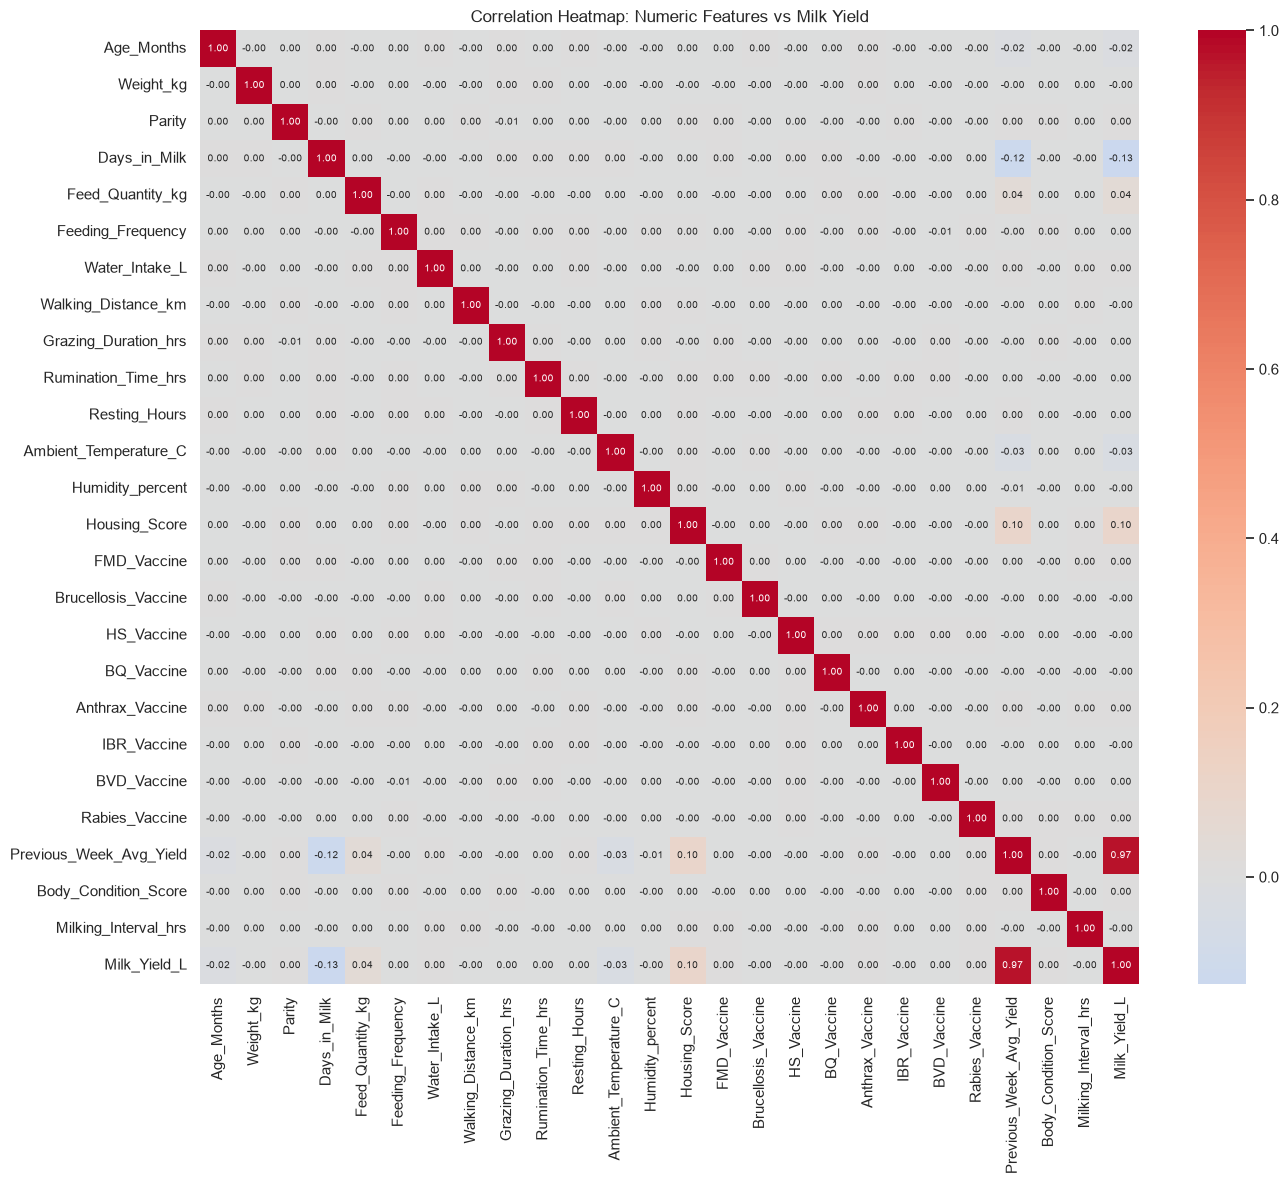

In [ ]:
plt.figure(figsize=(14, 12))
corr_matrix = df_clean[numeric_features + ["Milk_Yield_L"]].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Heatmap: Numeric Features vs Milk Yield")
plt.tight_layout()
plt.show()

**Interpretation:**  Previous_Week_Avg_Yield correlates with Milk_Yield_L at **0.97**, almost a straight line while every feeding/environmental/animal feature correlates weakly: Housing_Score at 0.10, Feed_Quantity_kg at only 0.04, Days_in_Milk at -0.13, and the rest even closer to 0.


### Histograms

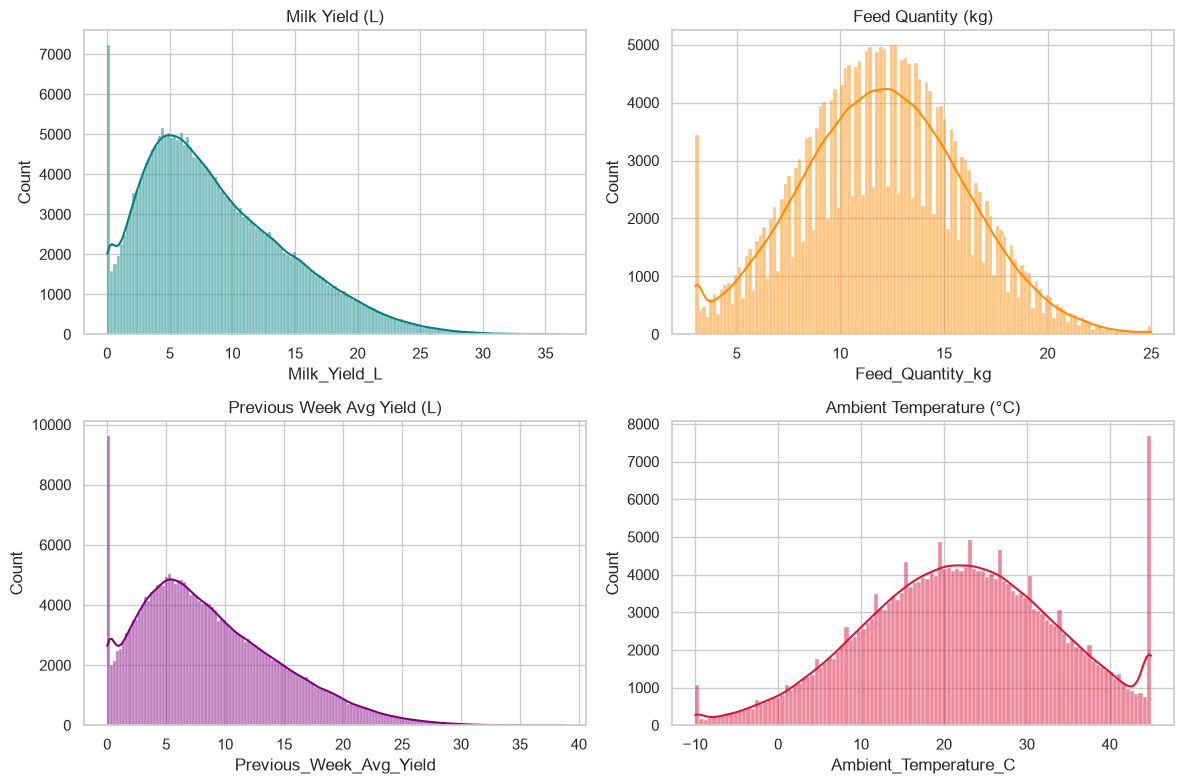

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_clean["Milk_Yield_L"], kde=True, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Milk Yield (L)")

sns.histplot(df_clean["Feed_Quantity_kg"], kde=True, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Feed Quantity (kg)")

sns.histplot(df_clean["Previous_Week_Avg_Yield"], kde=True, ax=axes[1, 0], color="purple")
axes[1, 0].set_title("Previous Week Avg Yield (L)")

sns.histplot(df_clean["Ambient_Temperature_C"], kde=True, ax=axes[1, 1], color="crimson")
axes[1, 1].set_title("Ambient Temperature (°C)")

plt.tight_layout()
plt.show()

**Interpretation:**

- **Milk Yield** is right-skewed with a hard floor at 0, representing dry (non-lactating) cows.
- **Feed Quantity** and **Previous Week Avg Yield** both look close to a smooth, roughly bell/right-skewed shape. No obvious data entry errors or outlier spikes.
- **Ambient Temperature** spans -10°C to 45°C in a fairly even spread, consistent with the dataset covering many different climate zones.

### Scatter Plots

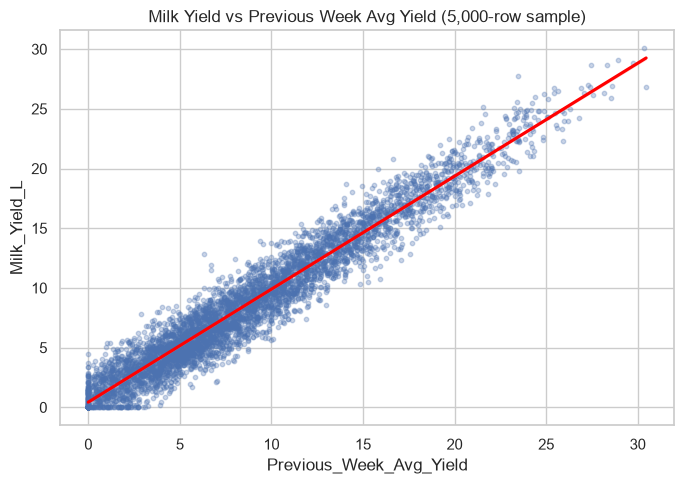

In [ ]:
sample = df_clean.sample(n=5000, random_state=RANDOM_STATE)

plt.figure(figsize=(7, 5))
sns.regplot(data=sample, x="Previous_Week_Avg_Yield", y="Milk_Yield_L",
            scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"})
plt.title("Milk Yield vs Previous Week Avg Yield (5,000-row sample)")
plt.tight_layout()
plt.show()

**Interpretation:** this confirms the heatmap's 0.97 correlation visually. This shows that there is a very strong positive relationship between milk yield and previous week average yield.

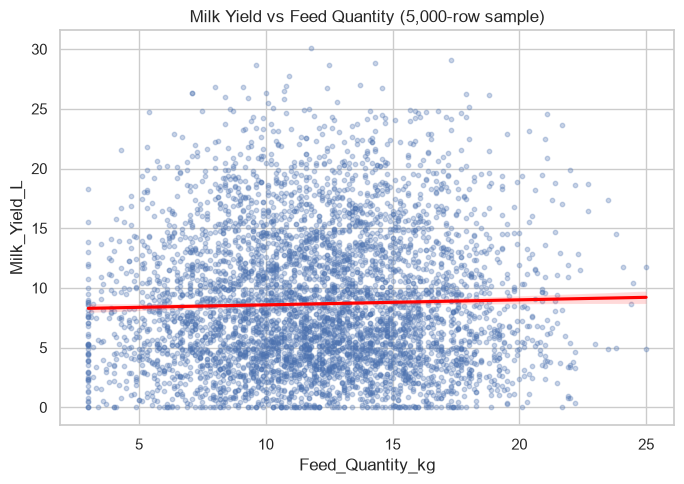

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(data=sample, x="Feed_Quantity_kg", y="Milk_Yield_L",
            scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"})
plt.title("Milk Yield vs Feed Quantity (5,000-row sample)")
plt.tight_layout()
plt.show()

**Interpretation:** unlike the previous plot, this is a wide, mostly formless cloud of points with only a very slight upward slope. Feeding more does not visibly translate into a large, obvious jump in same-day yield in this dataset. This suggests that the *momentum* of a cow's recent production matters far more than a single day's feed quantity. 

## Model Building

### Train/Test Split

We hold out **20% of the data for testing** and train on the remaining 80%. Since the model will not see our 20% test data, testing our model with this 20% data will help us understand how the model will perform when introduced to new records of another cow. **RANDOM_STATE** makes the split reproducible: anyone re-running this notebook gets the exact same train/test rows.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Milk_Yield_L"])
y = df_clean["Milk_Yield_L"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((200000, 31), (50000, 31))

### Preprocessing Pipeline

This is the time I am applying the encoding and scaling strategy I defined back in Feature Engineering, using ColumnTransformer to apply the right transformation to the right columns in one object:

- StandardScaler on all 25 numeric_features.
- OneHotEncoder on all 6 categorical_features 

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((200000, 92), (50000, 92))

**Interpretation:** the 31 original feature columns become **92 encoded columns** and the 25 numeric features stay as 25 (just rescaled), and the 6 categorical columns expand into 67 one-hot columns (Breed alone contributes 40 of them).

### Training the Four Models

#### Model 1: Linear Regression

No iteration needed 

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](92,)","[-0.01,-0. , 0.01,..., 0.02, 0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.72
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,92
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(86)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](92,)","[485.55,451.43,451.04,..., 0. , 0. , 0. ]"


#### Model 2: SGDRegressor (Gradient Descent)


In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, random_state=RANDOM_STATE)
sgd_reg.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1


#### Model 3: Decision Tree Regressor

It repeatedly splits the data into groups based on feature thresholds (e.g. "is Previous_Week_Avg_Yield above 8.1?")

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
tree_reg.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

#### Model 4: Random Forest Regressor

An ensemble of 100 decision trees, each trained on a random subset of rows and features, with predictions averaged across all of them.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

### Evaluating and Comparing the Models

To comepare the 4 models above, I will use three standard regression metrics, all computed on the same 20% test data that we split off our original dataset:

- **RMSE (Root Mean Squared Error)** - average prediction error in litres, with larger errors penalized more heavily. The Lower, the better.
- **MAE (Mean Absolute Error)** - average prediction error in litres, treating all errors equally. Lower is better.
- **R2 (Coefficient of Determination)** - the proportion of variation in milk yield the model explains, from 0  to 1. The Higher, the better.

We also compare **Train R2** with Test R2 - a large gap between them is the signature of overfitting (the model memorized training data instead of learning a generalizable pattern).

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    return {
        "Train R2": r2_score(y_tr, train_pred),
        "Test R2": r2_score(y_te, test_pred),
        "Test RMSE": mean_squared_error(y_te, test_pred) ** 0.5,
        "Test MAE": mean_absolute_error(y_te, test_pred),
    }

In [ ]:
models = {
    "Linear Regression": lin_reg,
    "SGDRegressor": sgd_reg,
    "Decision Tree": tree_reg,
    "Random Forest": rf_reg,
}

results = {
    name: evaluate_model(model, X_train_processed, y_train, X_test_processed, y_test)
    for name, model in models.items()
}

results_df = pd.DataFrame(results).T.sort_values("Test R2", ascending=False)
results_df

,Train R2,Test R2,Test RMSE,Test MAE
Linear Regression,0.943048,0.942903,1.376002,1.092893
SGDRegressor,0.942726,0.942679,1.378692,1.096088
Random Forest,0.947751,0.941896,1.388082,1.106481
Decision Tree,0.942449,0.938892,1.423505,1.133717


**Interpretation:**

| Model | Train R2 | Test R2 | Test RMSE | Test MAE |
|---|---|---|---|---|
| Linear Regression | 0.9430 | **0.9429** | **1.376 L** | **1.093 L** |
| SGDRegressor | 0.9427 | 0.9427 | 1.379 L | 1.096 L |
| Random Forest | **0.9478** | 0.9419 | 1.388 L | 1.106 L |
| Decision Tree | 0.9424 | 0.9389 | 1.424 L | 1.134 L |

**Linear Regression comes out on top on the test set**, though the margin over SGDRegressor is tiny (0.0002 R2, about 3 mL MAE difference). This shows that SGDRegressor solution is almost identical to the Linear Regression solution. This is just evidence that the gradient descent implementation is working correctly, not a reason to think one is better than the other.

From the correlation hitmap of Previous_week_Avg_Yield against Milk_Yield_L which had a highly positive correlation of 0.97, this is the most dorminant relationship in the data and it is linear. Linear Regression and SDGRegressor are the best models built to capture this kind of relationship efficiently. Random forest has the highest Train R2 of 0.9478 but the worst Train Test gap of 0.0059. This is shows that there is some overfitting in the Random Forest model. Decision tree is the worst of all the four models because it has the highest values of RMSE and MAE

Therefore, **We select Linear Regression as the best model** to carry forward for saving and the prediction function. It has the best test performance of all four models.

## Gradient Descent

This section looks inside SGDRegressor more closely than the other three models: we track how it learns.

### Tracking the Loss Curve

SGDRegressor.fit() runs its full training internally and only gives us the final result. To see the learning process, you instead call **.partial_fit()** yourself.

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

n_epochs = 50

sgd_gd = SGDRegressor(random_state=RANDOM_STATE, max_iter=1, tol=None, warm_start=True)

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    sgd_gd.partial_fit(X_train_processed, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_gd.predict(X_train_processed)))
    test_losses.append(mean_squared_error(y_test, sgd_gd.predict(X_test_processed)))

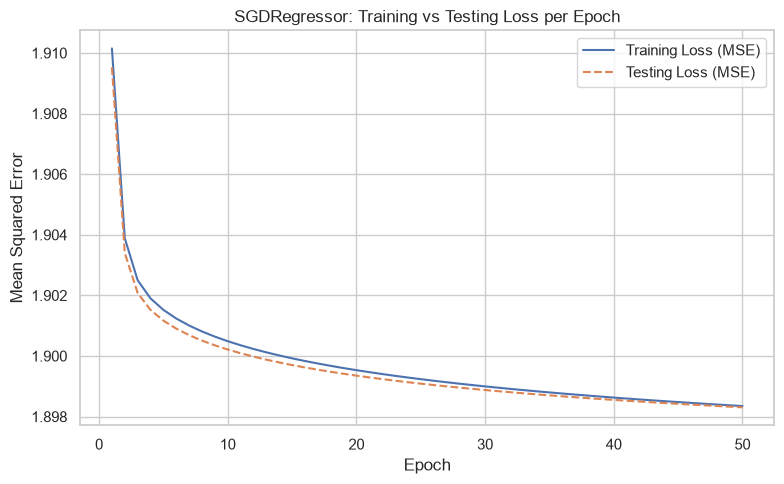

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="Training Loss (MSE)")
plt.plot(range(1, n_epochs + 1), test_losses, label="Testing Loss (MSE)", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGDRegressor: Training vs Testing Loss per Epoch")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** the loss starts around **1.91 MSE**, drops sharply over the first 5–10 epochs, and begins to flatten out towards the **1.898 MSE**

- **The curve converges quickly and smoothly** at the 50 epoch, with no bouncing around or divergence. The Mean Squared Error loss has exactly one minimum  of about 1.898 MSE
- **The training and testing curves sit almost exactly on top of each other** throughout. This shows that the model is not overfitting to the training data. Whatever it learns generalizes equally well to unseen cows.

## Visualizing the Best Model

Since LinearRegression was chosen as the best model, we now look specifically at how well its predictions track reality, and where it tends to get things wrong.

### Actual vs Predicted

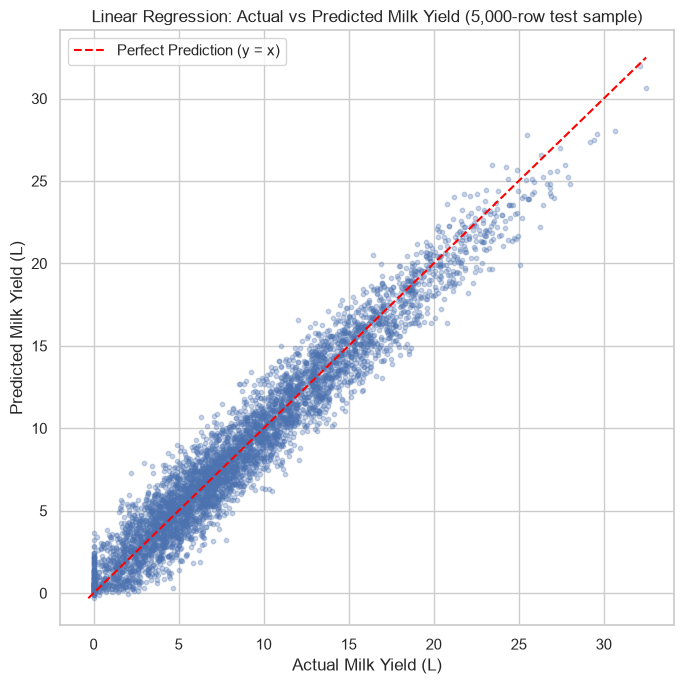

In [ ]:
best_model = lin_reg
test_predictions = best_model.predict(X_test_processed)

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(y_test), size=5000, replace=False)
y_test_sample = y_test.values[sample_idx]
pred_sample = test_predictions[sample_idx]

plt.figure(figsize=(7, 7))
plt.scatter(y_test_sample, pred_sample, alpha=0.3, s=10)

axis_min = min(y_test_sample.min(), pred_sample.min())
axis_max = max(y_test_sample.max(), pred_sample.max())
plt.plot([axis_min, axis_max], [axis_min, axis_max], color="red", linestyle="--",
         label="Perfect Prediction (y = x)")

plt.xlabel("Actual Milk Yield (L)")
plt.ylabel("Predicted Milk Yield (L)")
plt.title("Linear Regression: Actual vs Predicted Milk Yield (5,000-row test sample)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** the points cluster around the red y = x line across the entire range of yields. On average, the model is accurate and it is consistently accurate for both low-yield and high-yield cows.

However, the red line starts at a point below 0, meaning that some test predictions came out negative. Milk yield cannot be zero but our Linear Regression does not have that awareness.
We handle this directly in the final prediction function by clipping any negative output to 0.

### Residuals

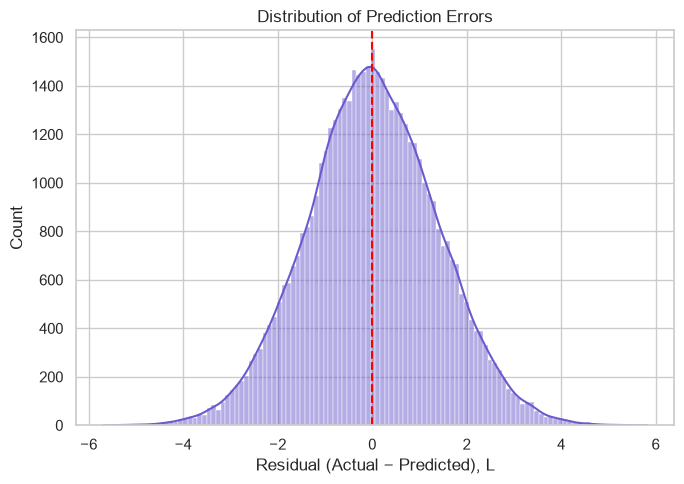

In [ ]:
residuals = y_test.values - test_predictions

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color="slateblue")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual − Predicted), L")
plt.title("Distribution of Prediction Errors")
plt.tight_layout()
plt.show()

**Interpretation:** the residuals are centred almost exactly on 0 and roughly symmetric . This shows that the errors in our model are small, unbiased, and centred at zero rather than skewed toward over or under-estimating a farmer's milk yield.

## Model Saving

### Bundling Preprocessing + Model into One Pipeline

**preprocessor** and the **LinearRegression** model are two separate fitted objects. We combine both fitted steps into a single **sklearn.pipeline.Pipeline**. Because **preprocessor** and **lin_reg** are already fitted, this does not retrain anything. It just wraps them so that one **.predict()** call on **raw, unprocessed** cow data does the encoding, scaling, and prediction internally, in the correct order, every time.

In [ ]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model),
])

In [ ]:
pipeline_predictions = full_pipeline.predict(X_test)
np.allclose(pipeline_predictions, test_predictions)

True

**Interpretation:** True confirms the pipeline's predictions on the raw X_test dataframe exactly match test_predictions from earlier, which we computed by manually preprocessing then calling lin_reg.predict()

### Saving to Disk

In [ ]:
import joblib  # it handles the NumPy arrays inside a fitted model more efficiently.

MODEL_PATH = "models/milk_yield_pipeline.joblib"
joblib.dump(full_pipeline, MODEL_PATH)

['models/milk_yield_pipeline.joblib']

### Prediction Function

 **Input one cow's information as a dictionary, get back a predicted daily milk yield in litres.**

In [ ]:
def predict_milk_yield(cow_info: dict) -> float:
    input_df = pd.DataFrame([cow_info])
    raw_prediction = full_pipeline.predict(input_df)[0]
    return round(max(0.0, raw_prediction), 2)

### Trying It Out

We test the function on a real cow from the test set (one the model never saw during training) and compare the prediction to what was actually recorded.

In [ ]:
example_cow = X_test.iloc[0].to_dict()
example_cow

{'Breed': 'Boran',
 'Climate_Zone': 'Mediterranean',
 'Management_System': 'Pastoral',
 'Age_Months': 38,
 'Weight_kg': 472.3,
 'Parity': 3,
 'Lactation_Stage': 'Mid',
 'Days_in_Milk': 342,
 'Feed_Type': 'Concentrates',
 'Feed_Quantity_kg': 10.4,
 'Feeding_Frequency': 3,
 'Water_Intake_L': 20.0,
 'Walking_Distance_km': 4.73,
 'Grazing_Duration_hrs': 7.1,
 'Rumination_Time_hrs': 4.5,
 'Resting_Hours': 11.0,
 'Ambient_Temperature_C': 2.7,
 'Humidity_percent': 72.5,
 'Season': 'Spring',
 'Housing_Score': 0.7,
 'FMD_Vaccine': 1,
 'Brucellosis_Vaccine': 0,
 'HS_Vaccine': 1,
 'BQ_Vaccine': 0,
 'Anthrax_Vaccine': 1,
 'IBR_Vaccine': 1,
 'BVD_Vaccine': 1,
 'Rabies_Vaccine': 1,
 'Previous_Week_Avg_Yield': 4.39,
 'Body_Condition_Score': 3.5,
 'Milking_Interval_hrs': 12}

In [ ]:
predicted_yield = predict_milk_yield(example_cow)
actual_yield = y_test.iloc[0]

print(f"Predicted daily milk yield: {predicted_yield} L")
print(f"Actual recorded milk yield: {actual_yield} L")

Predicted daily milk yield: 4.17 L
Actual recorded milk yield: 5.94 L


**Interpretation:** This particular cow's prediction is off by a bit more than the average error (consistent with the residual spread of about +-1.38 L we saw earlier). This is just a reminder that any single prediction can miss by more than the reported average.